# Exp 8: Fine-Tuned ViT + RoBERTa + Concat + MLP

**Run this on Google Colab with a T4/A100 GPU.**

**Goal:** Replicate best frozen architecture from Exp 6 (ViT-YOLO + RoBERTa + Concat + MLP) but with full end-to-end fine-tuning. Isolates the gain from fine-tuning alone.

**Architecture:**
```
Raw image → ViT (fine-tuned) → CLS [768]
Raw text  → RoBERTa (fine-tuned) → CLS [768]
         → img_proj + text_proj → Concat [2*proj_dim] → MLP → 1
```

**Frozen baseline AUC (Exp 6):** 0.6697

In [1]:
!pip install -q transformers
!pip install -q jsonlines

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from transformers import (
    RobertaTokenizer, RobertaModel,
    ViTModel, AutoImageProcessor,
    get_linear_schedule_with_warmup
)
from PIL import Image
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report
import matplotlib.pyplot as plt
import json, copy
import jsonlines
import warnings
warnings.filterwarnings('ignore')

In [2]:
import kagglehub, shutil, os, sys
from pathlib import Path

# Download dataset
path = kagglehub.dataset_download("parthplc/facebook-hateful-meme-dataset")
print("Downloaded to:", path)

# Check structure
for root, dirs, files in os.walk(path):
    for f in files[:5]:
        print(os.path.join(root, f))

Using Colab cache for faster access to the 'facebook-hateful-meme-dataset' dataset.
Downloaded to: /kaggle/input/facebook-hateful-meme-dataset
/kaggle/input/facebook-hateful-meme-dataset/data/dev.jsonl
/kaggle/input/facebook-hateful-meme-dataset/data/test.jsonl
/kaggle/input/facebook-hateful-meme-dataset/data/README.md
/kaggle/input/facebook-hateful-meme-dataset/data/LICENSE.txt
/kaggle/input/facebook-hateful-meme-dataset/data/train.jsonl
/kaggle/input/facebook-hateful-meme-dataset/data/img/52691.png
/kaggle/input/facebook-hateful-meme-dataset/data/img/37825.png
/kaggle/input/facebook-hateful-meme-dataset/data/img/06781.png
/kaggle/input/facebook-hateful-meme-dataset/data/img/49075.png
/kaggle/input/facebook-hateful-meme-dataset/data/img/73516.png


In [5]:
ROOT    = Path(path) / 'data'
IMG_DIR = ROOT / 'img'

os.makedirs('content/results', exist_ok=True)
os.makedirs('content/results',  exist_ok=True)
os.makedirs('content/results', exist_ok=True)

RESULTS_DIR = 'content/results'
MODELS_DIR  = 'content/models'
OUTPUTS_DIR = 'content/outputs'

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(OUTPUTS_DIR, exist_ok=True)

print(f'ROOT   : {ROOT}')
print(f'IMG_DIR: {IMG_DIR}')

ROOT   : /kaggle/input/facebook-hateful-meme-dataset/data
IMG_DIR: /kaggle/input/facebook-hateful-meme-dataset/data/img


In [6]:
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


## 1. Load Data

In [7]:
FROZEN_AUC = 0.6697  # Exp 6 concat result

def load_jsonl(path):
    data = []
    with jsonlines.open(path) as reader:
        for item in reader:
            data.append(item)
    return data

train_data = load_jsonl(ROOT / 'train.jsonl')
dev_data   = load_jsonl(ROOT / 'dev.jsonl')
print(f'Train: {len(train_data)} | Dev: {len(dev_data)}')
print(f'Sample: {train_data[0]}')

Train: 8500 | Dev: 500
Sample: {'id': 42953, 'img': 'img/42953.png', 'label': 0, 'text': 'its their character not their color that matters'}


## 2. Load Backbones

In [8]:
VIT_CKPT     = 'google/vit-base-patch16-224'
ROBERTA_CKPT = 'roberta-base'

print('Loading ViT...')
vit_extractor = AutoImageProcessor.from_pretrained(VIT_CKPT, use_fast=True)
vit_model     = ViTModel.from_pretrained(VIT_CKPT)
vit_model.gradient_checkpointing_enable()

print('Loading RoBERTa...')
rob_tokenizer = RobertaTokenizer.from_pretrained(ROBERTA_CKPT)
rob_model     = RobertaModel.from_pretrained(ROBERTA_CKPT)
rob_model.gradient_checkpointing_enable()

print(f'ViT params    : {sum(p.numel() for p in vit_model.parameters()):,}')
print(f'RoBERTa params: {sum(p.numel() for p in rob_model.parameters()):,}')

Loading ViT...


Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.bias   | MISSING    | 
pooler.dense.weight | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Loading RoBERTa...


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


ViT params    : 86,389,248
RoBERTa params: 124,645,632


## 3. Dataset & DataLoaders

In [9]:
MAX_LEN          = 64
BATCH_SIZE       = 16
GRAD_ACCUM_STEPS = 4

class HatefulMemesDataset(Dataset):
    def __init__(self, data, img_dir, tokenizer, feature_extractor, max_len=64):
        self.data              = data
        self.img_dir           = Path(img_dir)
        self.tokenizer         = tokenizer
        self.feature_extractor = feature_extractor
        self.max_len           = max_len

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item         = self.data[idx]
        image        = Image.open(self.img_dir / item['img'].split('/')[-1]).convert('RGB')
        pixel_values = self.feature_extractor(images=image, return_tensors='pt')['pixel_values'].squeeze(0)
        encoding     = self.tokenizer(
            item['text'], max_length=self.max_len,
            padding='max_length', truncation=True, return_tensors='pt'
        )
        return (pixel_values,
                encoding['input_ids'].squeeze(0),
                encoding['attention_mask'].squeeze(0),
                torch.tensor(item['label'], dtype=torch.float32))

train_ds = HatefulMemesDataset(train_data, IMG_DIR, rob_tokenizer, vit_extractor)
dev_ds   = HatefulMemesDataset(dev_data,   IMG_DIR, rob_tokenizer, vit_extractor)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
dev_loader   = DataLoader(dev_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

n_pos      = sum(d['label'] for d in train_data)
n_neg      = len(train_data) - n_pos
pos_weight = torch.tensor([n_neg / n_pos], dtype=torch.float32).to(DEVICE)
print(f'Train batches: {len(train_loader)} | Dev batches: {len(dev_loader)}')
print(f'Effective batch size: {BATCH_SIZE * GRAD_ACCUM_STEPS} | pos_weight: {pos_weight.item():.3f}')

Train batches: 532 | Dev batches: 32
Effective batch size: 64 | pos_weight: 1.787


## 4. Model

In [10]:
class FineTunedConcatMLP(nn.Module):
    def __init__(self, vit, roberta, proj_dim=256, d_proj=0.2, h1=128, h2=32, d1=0.3, d2=0.2):
        super().__init__()
        self.vit     = vit
        self.roberta = roberta
        self.img_proj  = nn.Sequential(nn.Linear(768, proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.text_proj = nn.Sequential(nn.Linear(768, proj_dim), nn.GELU(), nn.Dropout(d_proj))
        self.classifier = nn.Sequential(
            nn.Linear(proj_dim * 2, h1), nn.LayerNorm(h1), nn.GELU(), nn.Dropout(d1),
            nn.Linear(h1, h2),           nn.LayerNorm(h2), nn.GELU(), nn.Dropout(d2),
            nn.Linear(h2, 1)
        )

    def forward(self, pixel_values, input_ids, attention_mask):
        img_cls = self.vit(pixel_values=pixel_values).last_hidden_state[:, 0, :]
        txt_cls = self.roberta(input_ids=input_ids, attention_mask=attention_mask).last_hidden_state[:, 0, :]
        fused   = torch.cat([self.img_proj(img_cls), self.text_proj(txt_cls)], dim=-1)
        return self.classifier(fused).squeeze(-1)


# Fixed hyperparameters — no Optuna given memory/time constraints on Colab
PROJ_DIM = 256
model = FineTunedConcatMLP(vit_model, rob_model, proj_dim=PROJ_DIM).to(DEVICE)
print(f'Total params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

Total params: 211,498,753


## 5. Optimizer & Scheduler (Differential LR)

In [11]:
EPOCHS       = 10
PATIENCE     = 3
BACKBONE_LR  = 2e-5
CLF_LR       = 1e-4
WARMUP_RATIO = 0.1

backbone_params   = list(model.vit.parameters()) + list(model.roberta.parameters())
classifier_params = (list(model.img_proj.parameters()) +
                     list(model.text_proj.parameters()) +
                     list(model.classifier.parameters()))

optimizer = optim.AdamW([
    {'params': backbone_params,   'lr': BACKBONE_LR, 'weight_decay': 1e-2},
    {'params': classifier_params, 'lr': CLF_LR,      'weight_decay': 1e-4}
])

total_steps  = len(train_loader) // GRAD_ACCUM_STEPS * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)
criterion    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

print(f'Total steps: {total_steps} | Warmup steps: {warmup_steps}')
print(f'Backbone LR: {BACKBONE_LR:.1e} | Classifier LR: {CLF_LR:.1e}')

Total steps: 1330 | Warmup steps: 133
Backbone LR: 2.0e-05 | Classifier LR: 1.0e-04


## 6. Training Loop

In [12]:
from torch.cuda.amp import autocast, GradScaler
scaler = GradScaler()

def run_epoch(loader, model, criterion, optimizer=None, scheduler=None, grad_accum=1):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()
    total_loss, all_probs, all_labels = 0.0, [], []
    if is_train: optimizer.zero_grad()

    for step, (pv, ids, mask, y) in enumerate(loader):
        pv, ids, mask, y = pv.to(DEVICE), ids.to(DEVICE), mask.to(DEVICE), y.to(DEVICE)

        with autocast():
            logits = model(pv, ids, mask)
            loss   = criterion(logits, y)

        if is_train:
            scaler.scale(loss / grad_accum).backward()
            if (step + 1) % grad_accum == 0:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                if scheduler: scheduler.step()
                optimizer.zero_grad()

        total_loss += loss.item() * len(y)
        all_probs.extend(torch.sigmoid(logits).detach().float().cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    auc = roc_auc_score(all_labels, all_probs)
    acc = accuracy_score(all_labels, (np.array(all_probs) >= 0.5).astype(int))
    return total_loss / len(all_labels), auc, acc, np.array(all_probs), np.array(all_labels)


history = {'train_loss': [], 'dev_loss': [], 'train_auc': [], 'dev_auc': []}
best_dev_auc, best_state, patience_ctr = 0.0, None, 0

print('Fine-tuning: ViT + RoBERTa + Concat + MLP')
print('=' * 60)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_auc, tr_acc, _, _ = run_epoch(train_loader, model, criterion, optimizer, scheduler, GRAD_ACCUM_STEPS)
    dv_loss, dv_auc, dv_acc, _, _ = run_epoch(dev_loader,   model, criterion)
    history['train_loss'].append(tr_loss); history['dev_loss'].append(dv_loss)
    history['train_auc'].append(tr_auc);   history['dev_auc'].append(dv_auc)

    if dv_auc > best_dev_auc:
        best_dev_auc = dv_auc; best_state = copy.deepcopy(model.state_dict())
        patience_ctr = 0; flag = '  <- best'
    else:
        patience_ctr += 1; flag = f'  (patience {patience_ctr}/{PATIENCE})'

    print(f'Ep {epoch:02d} | Tr Loss {tr_loss:.4f} AUC {tr_auc:.4f} Acc {tr_acc:.4f} | '
          f'Dev Loss {dv_loss:.4f} AUC {dv_auc:.4f} Acc {dv_acc:.4f}{flag}')

    if patience_ctr >= PATIENCE:
        print(f'Early stopping at epoch {epoch}'); break

model.load_state_dict(best_state)
print(f'\nBest Dev AUC : {best_dev_auc:.4f}')
print(f'Frozen baseline: {FROZEN_AUC:.4f}')
print(f'Fine-tune delta: {best_dev_auc - FROZEN_AUC:+.4f}')

Fine-tuning: ViT + RoBERTa + Concat + MLP


`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Ep 01 | Tr Loss 0.8931 AUC 0.5597 Acc 0.5107 | Dev Loss 1.0241 AUC 0.6045 Acc 0.5740  <- best
Ep 02 | Tr Loss 0.7635 AUC 0.7471 Acc 0.7022 | Dev Loss 1.1063 AUC 0.6518 Acc 0.5940  <- best
Ep 03 | Tr Loss 0.6717 AUC 0.8200 Acc 0.7627 | Dev Loss 1.1558 AUC 0.6553 Acc 0.5800  <- best
Ep 04 | Tr Loss 0.5951 AUC 0.8651 Acc 0.8034 | Dev Loss 1.1304 AUC 0.6706 Acc 0.6040  <- best
Ep 05 | Tr Loss 0.5063 AUC 0.9069 Acc 0.8535 | Dev Loss 1.2865 AUC 0.6791 Acc 0.6120  <- best
Ep 06 | Tr Loss 0.4240 AUC 0.9339 Acc 0.8939 | Dev Loss 1.3676 AUC 0.6840 Acc 0.5960  <- best
Ep 07 | Tr Loss 0.3458 AUC 0.9546 Acc 0.9289 | Dev Loss 1.5889 AUC 0.6838 Acc 0.5860  (patience 1/3)
Ep 08 | Tr Loss 0.2911 AUC 0.9673 Acc 0.9484 | Dev Loss 1.4583 AUC 0.6784 Acc 0.6200  (patience 2/3)
Ep 09 | Tr Loss 0.2543 AUC 0.9744 Acc 0.9594 | Dev Loss 1.5729 AUC 0.6757 Acc 0.6060  (patience 3/3)
Early stopping at epoch 9

Best Dev AUC : 0.6840
Frozen baseline: 0.6697
Fine-tune delta: +0.0143


## 7. Training Curves

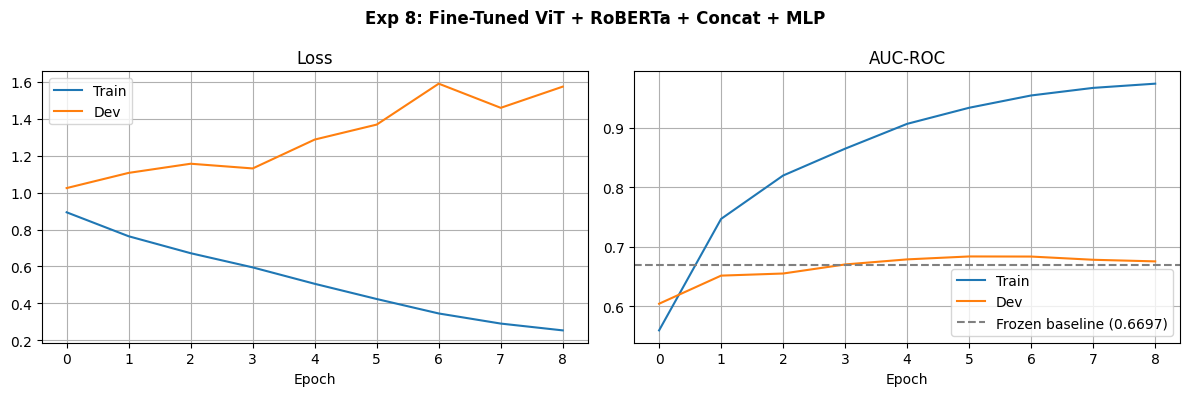

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history['train_loss'], label='Train'); axes[0].plot(history['dev_loss'], label='Dev')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(True)
axes[1].plot(history['train_auc'], label='Train'); axes[1].plot(history['dev_auc'], label='Dev')
axes[1].axhline(FROZEN_AUC, color='gray', linestyle='--', label=f'Frozen baseline ({FROZEN_AUC:.4f})')
axes[1].set_title('AUC-ROC'); axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(True)
plt.suptitle('Exp 8: Fine-Tuned ViT + RoBERTa + Concat + MLP', fontweight='bold')
plt.tight_layout()
plt.savefig('content/outputs/08_training_curves.png', dpi=150)
plt.show()

## 8. Evaluate & Save

In [15]:
_, dev_auc, dev_acc, dev_probs, dev_true = run_epoch(dev_loader, model, criterion)
dev_preds = (dev_probs >= 0.5).astype(int)
print('=' * 60)
print('EXP 8 — Fine-Tuned ViT + RoBERTa + Concat + MLP | Dev Set')
print('=' * 60)
print(f'AUC-ROC  : {dev_auc:.4f}')
print(f'Accuracy : {dev_acc:.4f}')
print(f'vs Frozen: {dev_auc - FROZEN_AUC:+.4f}')
print()
print(classification_report(dev_true, dev_preds, target_names=['Not Hateful', 'Hateful']))

torch.save(best_state, 'content/models/08_vit_roberta_finetuned_concat_mlp.pt')

exp8_out = {
    'experiment': '08_FineTuned_Concat_MLP',
    'image_backbone': 'vit-base-patch16-224 (fine-tuned)',
    'text_backbone':  'roberta-base (fine-tuned)',
    'pipeline': 'ViT CLS + RoBERTa CLS -> proj -> concat -> MLP',
    'frozen_baseline_auc': FROZEN_AUC,
    'results': {
        'dev_auc_roc':     round(float(dev_auc), 4),
        'dev_accuracy':    round(float(dev_acc), 4),
        'delta_vs_frozen': round(float(dev_auc - FROZEN_AUC), 4)
    },
    'training': {
        'epochs_run':           len(history['dev_auc']),
        'batch_size':           BATCH_SIZE,
        'grad_accum_steps':     GRAD_ACCUM_STEPS,
        'effective_batch_size': BATCH_SIZE * GRAD_ACCUM_STEPS,
        'backbone_lr':          BACKBONE_LR,
        'clf_lr':               CLF_LR
    }
}
with open('content/results/exp8.json', 'w') as f:
    json.dump(exp8_out, f, indent=2)

print('Model   -> models/08_vit_roberta_finetuned_concat_mlp.pt')
print('Results -> results/exp8.json')
print(json.dumps(exp8_out, indent=2))

EXP 8 — Fine-Tuned ViT + RoBERTa + Concat + MLP | Dev Set
AUC-ROC  : 0.6840
Accuracy : 0.5960
vs Frozen: +0.0143

              precision    recall  f1-score   support

 Not Hateful       0.56      0.85      0.68       250
     Hateful       0.69      0.34      0.46       250

    accuracy                           0.60       500
   macro avg       0.63      0.60      0.57       500
weighted avg       0.63      0.60      0.57       500

Model   -> models/08_vit_roberta_finetuned_concat_mlp.pt
Results -> results/exp8.json
{
  "experiment": "08_FineTuned_Concat_MLP",
  "image_backbone": "vit-base-patch16-224 (fine-tuned)",
  "text_backbone": "roberta-base (fine-tuned)",
  "pipeline": "ViT CLS + RoBERTa CLS -> proj -> concat -> MLP",
  "frozen_baseline_auc": 0.6697,
  "results": {
    "dev_auc_roc": 0.684,
    "dev_accuracy": 0.596,
    "delta_vs_frozen": 0.0143
  },
  "training": {
    "epochs_run": 9,
    "batch_size": 16,
    "grad_accum_steps": 4,
    "effective_batch_size": 64,
    "